# PVGIS-only ST-GNN — Monaco neural-SDE (drift/diffusion) pipeline

Reproducible orchestrator for the final run on server **newzealand**.

Does **not** duplicate runner/analysis logic — it builds commands and reads the
CSVs they write, via `physiq_pv.experiments.sde_pipeline`.

Safety switches: `RUN_TRAINING`, `RUN_ANALYSIS`, `RUN_SWEEP`, `CREATE_SWEEP`, `LOG_TO_WANDB`.

## 1. Setup

In [1]:
import os, sys, subprocess
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
os.environ['PYTHONPATH'] = str(REPO_ROOT) + os.pathsep + os.environ.get('PYTHONPATH', '')
os.chdir(REPO_ROOT)

from physiq_pv.experiments import sde_pipeline as pipe
print('repo root:', REPO_ROOT)

repo root: /home/apedalino/physiq_pv


In [2]:
PVGIS_DIR = pipe.PVGIS_DIR
EXPERIMENT = 'normal_only'  # 'baseline' | 'normal_only'
ANOMALY_SOURCE = 'detector'  # 'climatology' | 'detector'
DETECTOR = 'mtgflow'  # 'mtgflow' | 'catch' | 'm2ad'
DETECTOR_SEED = 15
DETECTOR_ROOTS = {
    'mtgflow': Path('outputs/pvgis_mtgflow/downstream_dense') / f'seed_{DETECTOR_SEED}',
    'catch': Path('outputs/pvgis_catch_2005_2019'),
    'm2ad': Path('outputs/pvgis_m2ad_2005_2019'),
}
DETECTOR_ROOT = DETECTOR_ROOTS[DETECTOR]
if ANOMALY_SOURCE == 'detector':
    TEST_ANOMALY_SCORES = str(DETECTOR_ROOT / 'anomaly_scores.csv')
    TRAIN_ANOMALY_SCORES = str(DETECTOR_ROOT / 'train_anomaly_scores.csv')
else:
    TEST_ANOMALY_SCORES = pipe.TEST_ANOMALY_SCORES
    TRAIN_ANOMALY_SCORES = pipe.TRAIN_ANOMALY_SCORES
ANALYSIS_SCRIPT = pipe.ANALYSIS_SCRIPT

NEEDS_TRAIN_ANOMALIES = EXPERIMENT == 'normal_only'
checks = {
    'PVGIS dir': Path(PVGIS_DIR).is_dir(),
    'test anomaly scores': Path(TEST_ANOMALY_SCORES).exists(),
    'train anomaly scores': (not NEEDS_TRAIN_ANOMALIES) or Path(TRAIN_ANOMALY_SCORES).exists(),
    'analysis script': Path(ANALYSIS_SCRIPT).exists(),
}
try:
    import physiq_pv.experiments.pvgis_stgnn_runner  # noqa: F401
    checks['runner importable'] = True
except Exception as e:
    checks['runner importable'] = False
    print('runner import error:', e)
for k, v in checks.items():
    print(('OK     ' if v else 'MISSING') + '  ' + k)

OK       PVGIS dir
OK       test anomaly scores
OK       train anomaly scores
OK       analysis script
OK       runner importable


If the anomaly scores are **missing**, regenerate them (run in a terminal — not launched automatically):

In [3]:
if not Path(TEST_ANOMALY_SCORES).exists() or (NEEDS_TRAIN_ANOMALIES and not Path(TRAIN_ANOMALY_SCORES).exists()):
    if ANOMALY_SOURCE == 'detector':
        detector_notebook = {'mtgflow': 'mtgflow_pvgis_workflow.ipynb', 'catch': 'pvgis_catch_pipeline.ipynb', 'm2ad': 'pvgis_m2ad_pipeline.ipynb'}[DETECTOR]
        print(f'Mancano i CSV {DETECTOR}: eseguire prima notebooks/{detector_notebook}')
    else:
        base = ('PYTHONPATH=$PWD python scripts/run_pvgis_climatology_anomaly_years.py'
            ' --pvgis-dir ' + PVGIS_DIR +
            ' --climatology-start-year 2005 --climatology-end-year 2018'
            ' --rolling-past-climatology'
            ' --quantile 0.975 --climatology-window-days 15 --min-climatology-years 3'
            ' --variables solar_irradiance_poa pv_power_output temperature_2m wind_speed_10m'
            ' --out-root outputs')
        print('# Test year 2019:')
        print(base + ' --years 2019')
        print()
        print('# Train years 2016-2018 (aggregated):')
        print(base + ' --years 2016,2017,2018 --aggregate-out-dir ' + str(Path(TRAIN_ANOMALY_SCORES).parent))
else:
    print('anomaly scores present.')

anomaly scores present.


## 2. Single-run config

In [4]:
# === EXPERIMENT SELECTOR ===
# normal_only = aggregate local anomalies into graph-wide events, then
# physically remove train/validation windows whose target, 24h history,
# or two-hour derived-feature lookback contains a rare event;
# retained windows keep every node and labels are
# never model inputs or prediction targets; test remains complete.
SIGMA_MAX = 1.0              # 0.5 = Monaco baseline; change here for ablations

_OVERRIDES = {
    'baseline': {},
    # Requires TRAIN-year anomaly
    # scores to select graph-wide normal-event windows in the effective train years.
    'normal_only': {'epochs': 60, 'train_normal_only': True},
}

BASE_CONFIG = {**pipe.DEFAULT_CONFIG, **_OVERRIDES[EXPERIMENT],
               'anomaly_source': ANOMALY_SOURCE,
               'detector_min_location_fraction': 0.01,
               'sigma_max': SIGMA_MAX,
               'mc_samples': 20,
               'name': f'{EXPERIMENT}_{ANOMALY_SOURCE}_{DETECTOR if ANOMALY_SOURCE == "detector" else "climatology"}_sigma{SIGMA_MAX:g}_ep60'}

out_dir = pipe.make_out_dir(BASE_CONFIG)
run_name = pipe.make_run_name(BASE_CONFIG)
print('experiment:', EXPERIMENT)
print('config    :', BASE_CONFIG)
print('out_dir   :', out_dir)
print('run_name  :', run_name)
if Path(out_dir).exists():
    print('WARNING: out_dir already exists — a run would overwrite its files.')

experiment: normal_only
config    : {'train_years': '2016,2017,2018', 'validation_year': 2018, 'test_year': 2019, 'seq_len': 24, 'horizon': 1, 'target_variable': 'pv_power_output', 'model_type': 'stgnn', 'feature_set': 'full', 'epochs': 60, 'batch_size': 16, 'lr': 0.0001, 'dropout': 0.0, 'mc_samples': 20, 'seed': 42, 'n_sde_steps': 2, 'sigma_max': 1.0, 'ood_noise_std': 1.0, 'irradiance_loss_weight': 0.1, 'pv_target_clip_max': 'none', 'kt_poa_max': 1.6, 'distance_scale_km': 10.0, 'edge_prior_strength': 1.0, 'validation_metric': 'rmse_daytime', 'early_stopping_patience': 10, 'early_stopping_min_delta': 0.0, 'event_spatial_quantile': 0.99, 'event_tail_quantile': 0.975, 'train_normal_only': True, 'name': 'normal_only_sigma1_ep60'}
out_dir   : outputs/pvgis_stgnn_normal_only_sigma1_ep60_seed42
run_name  : pvgis_stgnn_normal_only_sigma1_ep60_seed42


## 3. Training command

In [5]:
train_cmd = pipe.build_train_command(
    BASE_CONFIG, out_dir=out_dir, run_name=run_name,
    pvgis_dir=PVGIS_DIR, test_anomaly_scores=TEST_ANOMALY_SCORES,
    train_anomaly_scores=TRAIN_ANOMALY_SCORES, device='cuda', use_wandb=True)
# Keep W&B run logging enabled, but do not upload runner artifacts.
assert '--wandb' in train_cmd
assert '--no-wandb-upload-artifacts' in train_cmd
print(' \\\n  '.join(train_cmd))

/home/apedalino/physiq_pv/.venv/bin/python \
  -m \
  physiq_pv.experiments.pvgis_stgnn_runner \
  --pvgis-dir \
  /data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance \
  --anomaly-scores \
  outputs/pvgis_anomaly_2019_2005_2018_w15_q0975/pvgis_climatology_scores.csv \
  --train-years \
  2016,2017,2018 \
  --validation-year \
  2018 \
  --test-year \
  2019 \
  --seq-len \
  24 \
  --horizon \
  1 \
  --target-variable \
  pv_power_output \
  --model-type \
  stgnn \
  --feature-set \
  full \
  --irradiance-loss-weight \
  0.1 \
  --epochs \
  60 \
  --batch-size \
  16 \
  --lr \
  0.0001 \
  --dropout \
  0.0 \
  --mc-samples \
  20 \
  --pv-target-clip-max \
  none \
  --seed \
  42 \
  --n-sde-steps \
  2 \
  --sigma-max \
  1.0 \
  --ood-noise-std \
  1.0 \
  --kt-poa-max \
  1.6 \
  --distance-scale-km \
  10.0 \
  --edge-prior-strength \
  1.0 \
  --validation-metric \
  rmse_daytime \
  --early-stopping-patience \
  10 \
  --early-stopping-min-delta \
  0.0 \
  --event-s

## 4. Run training

Set `RUN_TRAINING = True` to actually launch.

In [6]:
RUN_TRAINING = True

if RUN_TRAINING:
    subprocess.run(train_cmd, check=True)
else:
    print('RUN_TRAINING is False — not launching. Command above is what would run.')

INFO: paper-style protocol — predictive intervals are built directly from the SDE Brownian-path sample distribution (lower_pi/upper_pi, empirical quantiles). The Gaussian band (mean +/- 1.96*std_raw) is logged only as a secondary diagnostic. 


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/apedalino/.netrc.
wandb: Currently logged in as: albertopedalino (albertopedalino-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /home/apedalino/physiq_pv/wandb/run-20260725_201908-kzxjb4p0
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pvgis_stgnn_normal_only_sigma1_ep60_seed42
wandb: ⭐️ View project at https://wandb.ai/albertopedalino-politecnico-di-torino/physiq_pv
wandb: 🚀 View run at https://wandb.ai/albertopedalino-politecnico-di-torino/physiq_pv/runs/kzxjb4p0


[wandb] run id=kzxjb4p0 name=pvgis_stgnn_normal_only_sigma1_ep60_seed42 -> out_dir=outputs/pvgis_stgnn_normal_only_sigma1_ep60_seed42
[wandb] run metadata -> outputs/pvgis_stgnn_normal_only_sigma1_ep60_seed42/wandb_run.json
[config] seed=42  batch_size=16  epochs=60  mc_samples=20  skip_predictions_csv=False  train_years=2016,2017,2018  validation_year=2018  test_year=2019  pv_target_clip_max=None  n_sde_steps=2  sigma_max=1.0  ood_noise_std=1.0  lr_g=None  train_normal_only=True  event_spatial_quantile=0.99  event_tail_quantile=0.975  use_irradiance_head=True  use_irradiance_loss=True  irradiance_loss_weight=0.1  kt_poa_max=1.6  distance_scale_km=10.0  edge_prior_strength=1.0  validation_metric=rmse_daytime  early_stopping_patience=10  out_dir=outputs/pvgis_stgnn_normal_only_sigma1_ep60_seed42
[1/6] Loading PVGIS years (train+validation=[2016, 2017, 2018], validation=2018, test=2019) | model=stgnn feature_set=full n_features=11
  [ok]   loaded PVGIS year 2016: piedmont_pvgis_2016.nc
 

wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 60-60, summary, console lines 91-831
wandb: 
wandb: Run history:
wandb:                                best_epoch ▁
wandb:                     best_validation_score ▁
wandb:                      clc_gaussian/daytime ▁
wandb:                 clc_gaussian/event_normal ▁
wandb:         clc_gaussian/event_normal_daytime ▁
wandb:       clc_gaussian/event_normal_nighttime ▁
wandb:           clc_gaussian/event_rare_extreme ▁
wandb:   clc_gaussian/event_rare_extreme_daytime ▁
wandb: clc_gaussian/event_rare_extreme_nighttime ▁
wandb:         clc_gaussian/extreme_peak_daytime ▁
wandb:                                      +717 ...
wandb: 
wandb: Run summary:
wandb:                                best_epoch 60
wandb:                    best_validation_metric rmse_daytime
wandb:                     best_validation_score 59.56518
wandb:                      clc

## 5. Post-hoc analysis

In [7]:
RUN_ANALYSIS = True

analysis_cmd = pipe.build_analysis_command(out_dir, BASE_CONFIG)
print(' \\\n  '.join(analysis_cmd))
if RUN_ANALYSIS:
    subprocess.run(analysis_cmd, check=True)
else:
    print('RUN_ANALYSIS is False — not launching.')

/home/apedalino/physiq_pv/.venv/bin/python \
  scripts/analyze_pvgis_daytime_report.py \
  --predictions \
  outputs/pvgis_stgnn_normal_only_sigma1_ep60_seed42/predictions.csv \
  --out-dir \
  outputs/pvgis_stgnn_normal_only_sigma1_ep60_seed42 \
  --epochs \
  60 \
  --dropout \
  0.0 \
  --mc-samples \
  20 \
  --train-normal-only
[load] scanned 10,037,664 rows; 4,747,545 daytime candidates (solar > 10.0 W/m^2); kept 4,747,545 valid, skipped 0 invalid; 5,290,119 nighttime
[sharpness] target_range = 891.8600 (y_true_min 1.4100, y_true_max 893.2700)
[done] wrote:
  outputs/pvgis_stgnn_normal_only_sigma1_ep60_seed42/daytime_bin_anomaly_report.md
  outputs/pvgis_stgnn_normal_only_sigma1_ep60_seed42/daytime_anomaly_overview.csv
  outputs/pvgis_stgnn_normal_only_sigma1_ep60_seed42/daytime_bin_summary.csv
  outputs/pvgis_stgnn_normal_only_sigma1_ep60_seed42/daytime_bin_anomaly_metrics.csv
  outputs/pvgis_stgnn_normal_only_sigma1_ep60_seed42/frequency_weighted_bin_summary.csv
  outputs/pvgis

## 6. Results & figures

Reads the CSVs the runner/analysis wrote, then shows: summary tables, the
SDE band (predictive std) by anomaly group, and the post-hoc figures
(histograms + boxplots). Monaco SDE U-Net: one total uncertainty band
(SDE-sample spread), no aleatoric/epistemic split.

In [8]:
def _read(name):
    p = Path(out_dir) / name
    return pd.read_csv(p) if p.exists() else None

RESULT_FILES = ['metrics_global.csv','metrics_daytime.csv','metrics_by_anomaly_label.csv',
                'residual_bias_and_bin_metrics.csv','daytime_bin_summary.csv',
                'daytime_bin_anomaly_metrics.csv','uncertainty_response.csv','sharpness_overview.csv']
results = {n: _read(n) for n in RESULT_FILES}
for n, df in results.items():
    print((('OK  ' if df is not None else '--  ') + n) + (('  ' + str(df.shape)) if df is not None else ''))

OK  metrics_global.csv  (1, 9)
OK  metrics_daytime.csv  (18, 26)
OK  metrics_by_anomaly_label.csv  (8, 9)
OK  residual_bias_and_bin_metrics.csv  (19, 24)
OK  daytime_bin_summary.csv  (5, 9)
OK  daytime_bin_anomaly_metrics.csv  (30, 13)
OK  uncertainty_response.csv  (5, 8)
OK  sharpness_overview.csv  (7, 11)


In [9]:
sharp = results['sharpness_overview.csv']
if sharp is not None:
    cols = [c for c in ['scope','count','picp','mae','rmse','mean_std','mpiw','nmpil'] if c in sharp.columns]
    display(sharp[cols])
bins = results['daytime_bin_summary.csv']
if bins is not None:
    display(bins)
unc = results['uncertainty_response.csv']
if unc is not None:
    display(unc)

,scope,count,picp,mae,rmse,mean_std,mpiw,nmpil
0,overall_daytime,4747545,0.264337,38.043446,65.044886,5.895061,20.218534,0.022670
1,normal,4156850,0.263813,37.407318,63.524858,5.873953,20.145459,0.022588
2,rare_extreme,590695,0.268023,42.520017,74.874016,6.043598,20.732778,0.023247
3,unusually_low_solar_potential,96867,0.021958,78.689013,115.691713,5.753194,19.731344,0.022124
4,unusually_high_solar_potential,39289,0.125684,48.425975,74.422677,7.786770,26.756600,0.030001
5,extreme_temperature_condition,273209,0.398402,26.367584,52.680854,5.879432,20.167594,0.022613
6,extreme_wind_condition,228107,0.233846,45.770615,75.349605,6.135400,21.044630,0.023596


,bin,count,mae,rmse,picp,mean_std,mpiw,nmpil,production_peak_nmpil
0,daytime_0_20_pct,1934608,32.112187,57.835276,0.218411,4.569845,15.658643,0.017557,0.021963
1,daytime_20_40_pct,856630,43.066637,66.805705,0.305390,6.834512,23.437266,0.026279,0.032874
2,daytime_40_60_pct,736468,41.198400,66.638357,0.365667,7.096757,24.349766,0.027302,0.034154
3,daytime_60_80_pct,669745,41.981389,74.849376,0.285179,6.522072,22.376577,0.025090,0.031386
4,daytime_80_100_pct,550094,42.062217,70.951422,0.200886,6.720487,23.084374,0.025883,0.032379


,category,mae_ratio_vs_normal,rmse_ratio_vs_normal,std_ratio_vs_normal,picp_delta_vs_normal,mpiw_ratio_vs_normal,nmpil_ratio_vs_normal,underdispersion_flag
0,rare_extreme,1.136676,1.178657,1.028881,0.004211,1.029154,1.029154,True
1,unusually_low_solar_potential,2.103573,1.821204,0.979442,-0.241855,0.979444,0.979444,True
2,unusually_high_solar_potential,1.294559,1.171552,1.325644,-0.138129,1.328170,1.328170,False
3,extreme_temperature_condition,0.704878,0.829295,1.000933,0.134589,1.001099,1.001099,False
4,extreme_wind_condition,1.223574,1.186144,1.044509,-0.029966,1.044634,1.044634,True


In [10]:
# SDE band (total predictive std) by anomaly group. Monaco does not split
# aleatoric/epistemic: the band is the spread of the SDE samples. Seasonal
# anomaly labels are evaluation strata only.
_pred = Path(out_dir) / 'predictions.csv'
if _pred.exists():
    _df = pd.read_csv(_pred, usecols=['anomaly_group', 'solar_irradiance_poa_target',
                                      'y_pred_std'])
    _day = _df[_df['solar_irradiance_poa_target'] > 10.0]
    display(_day.groupby('anomaly_group')[['y_pred_std']].mean())
else:
    print('predictions.csv not found — run training first.')

,y_pred_std
anomaly_group,
normal,5.873953
rare_or_extreme,6.043598


In [11]:
MAX_PLOT_ROWS = 500_000
figure_paths = pipe.build_posthoc_figures(out_dir, max_plot_rows=MAX_PLOT_ROWS, random_state=1)
print('figures:', list(figure_paths))

figures: ['mae_daytime_0_20_pct_boxplot', 'mae_daytime_20_40_pct_boxplot', 'mae_daytime_40_60_pct_boxplot', 'mae_daytime_60_80_pct_boxplot', 'mae_daytime_80_100_pct_boxplot', 'nmpil_daytime_0_20_pct_boxplot', 'nmpil_daytime_20_40_pct_boxplot', 'nmpil_daytime_40_60_pct_boxplot', 'nmpil_daytime_60_80_pct_boxplot', 'nmpil_daytime_80_100_pct_boxplot', 'picp_daytime_0_20_pct_bar', 'picp_daytime_20_40_pct_bar', 'picp_daytime_40_60_pct_bar', 'picp_daytime_60_80_pct_bar', 'picp_daytime_80_100_pct_bar', 'clc_daytime_0_20_pct_bar', 'clc_daytime_20_40_pct_bar', 'clc_daytime_40_60_pct_bar', 'clc_daytime_60_80_pct_bar', 'clc_daytime_80_100_pct_bar', 'rmse_daytime_0_20_pct_bar', 'rmse_daytime_20_40_pct_bar', 'rmse_daytime_40_60_pct_bar', 'rmse_daytime_60_80_pct_bar', 'rmse_daytime_80_100_pct_bar']


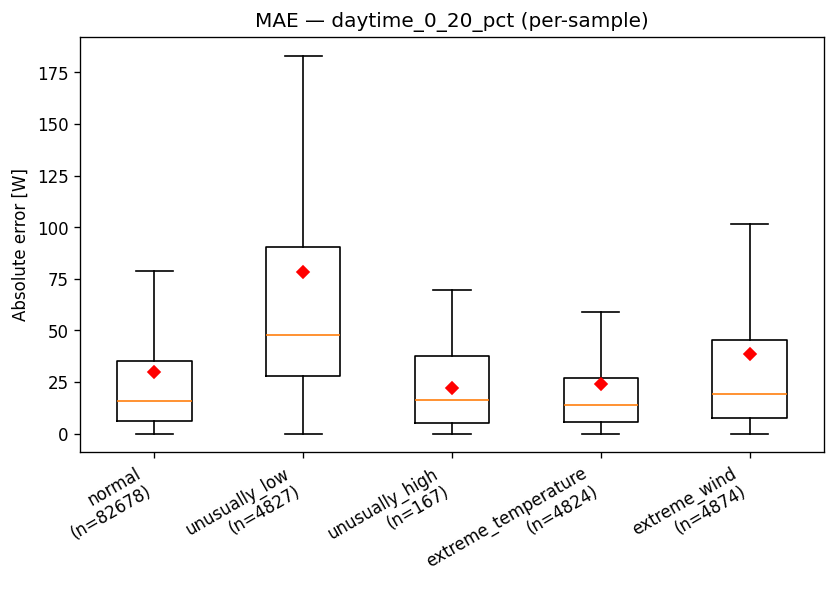

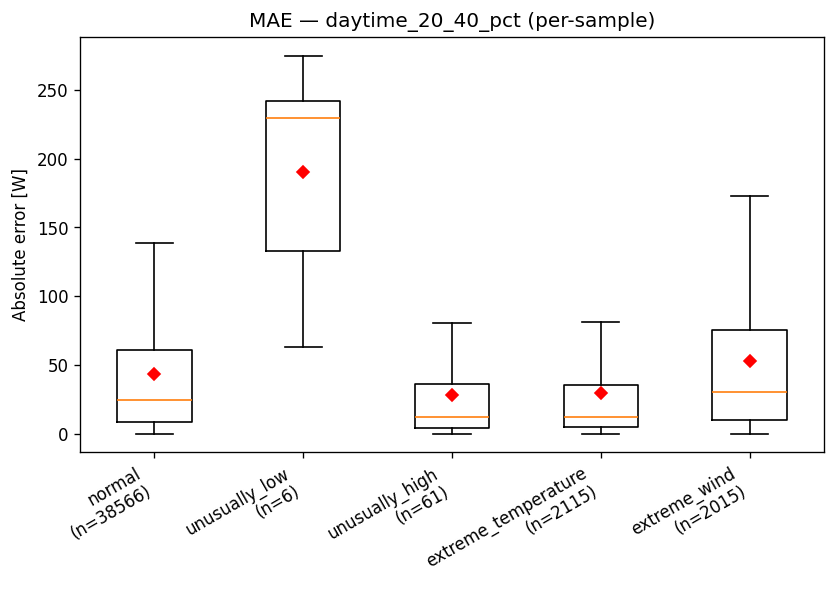

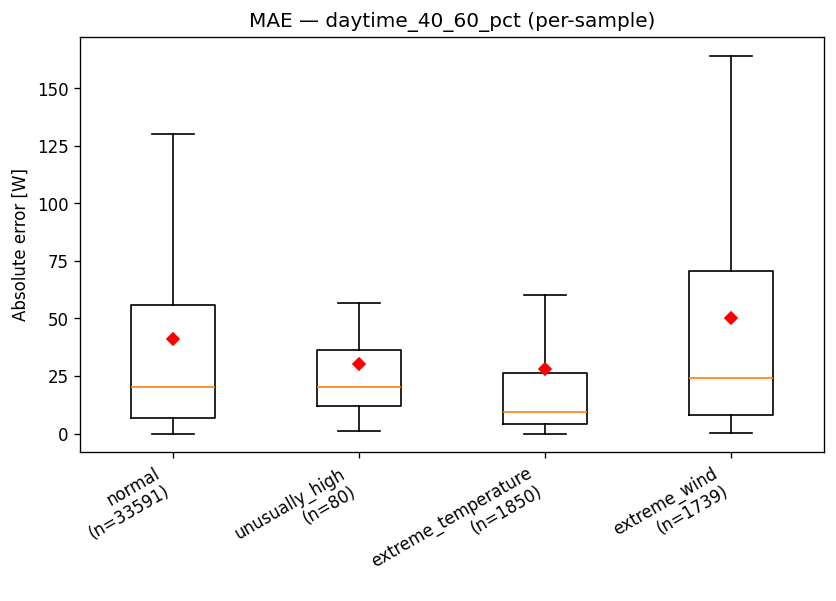

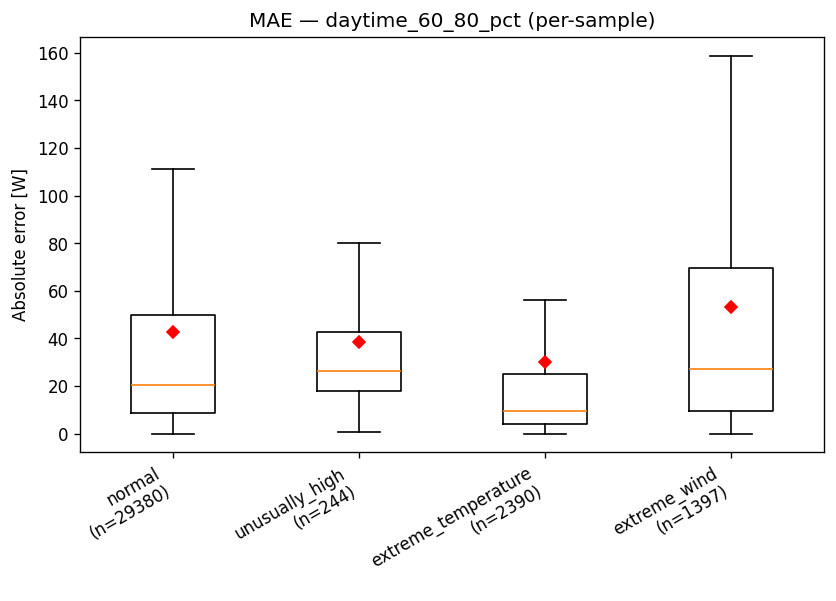

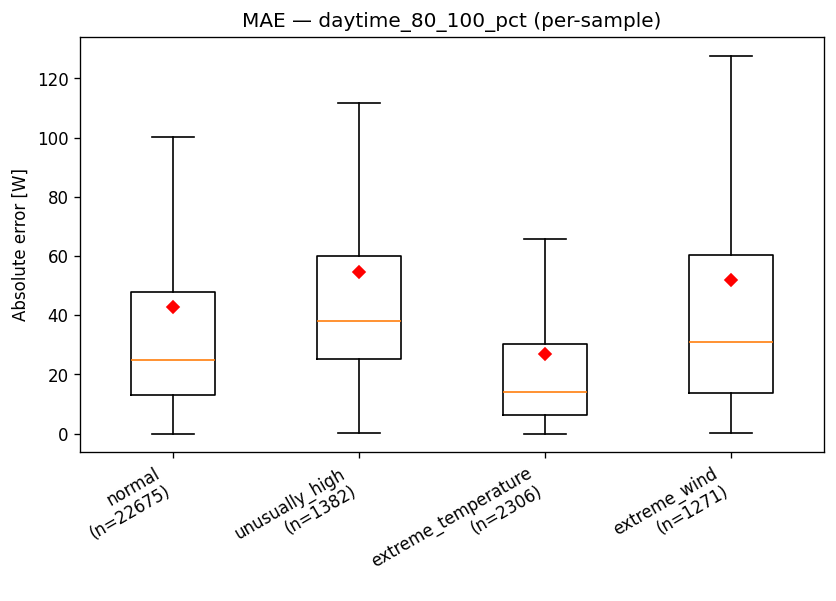

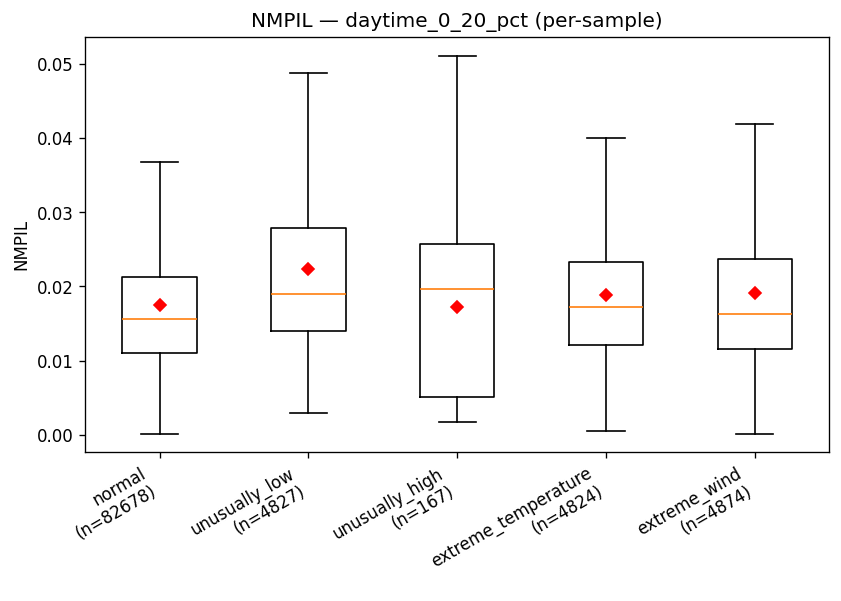

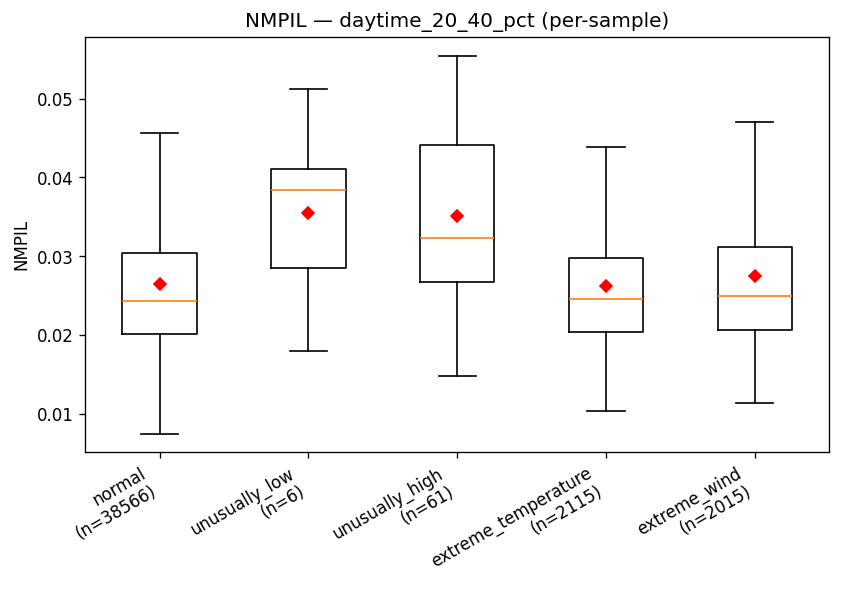

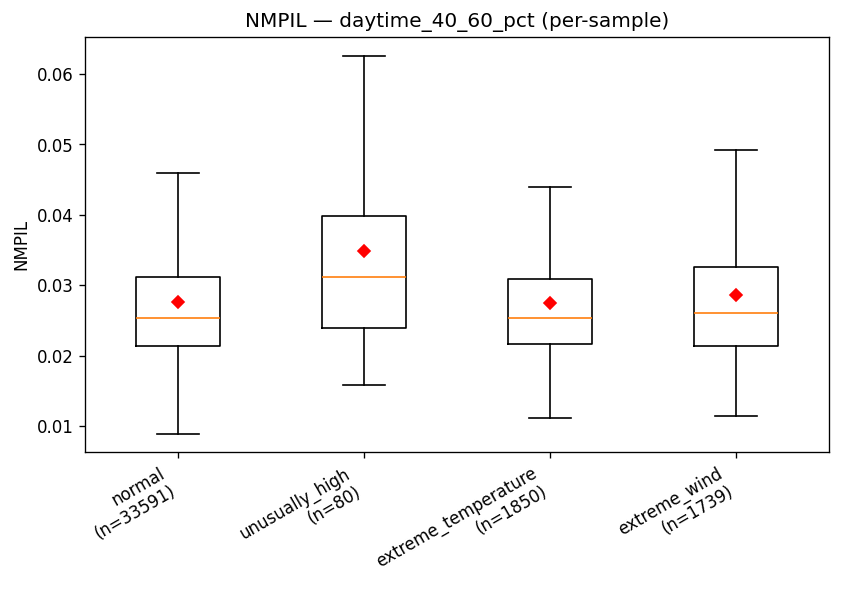

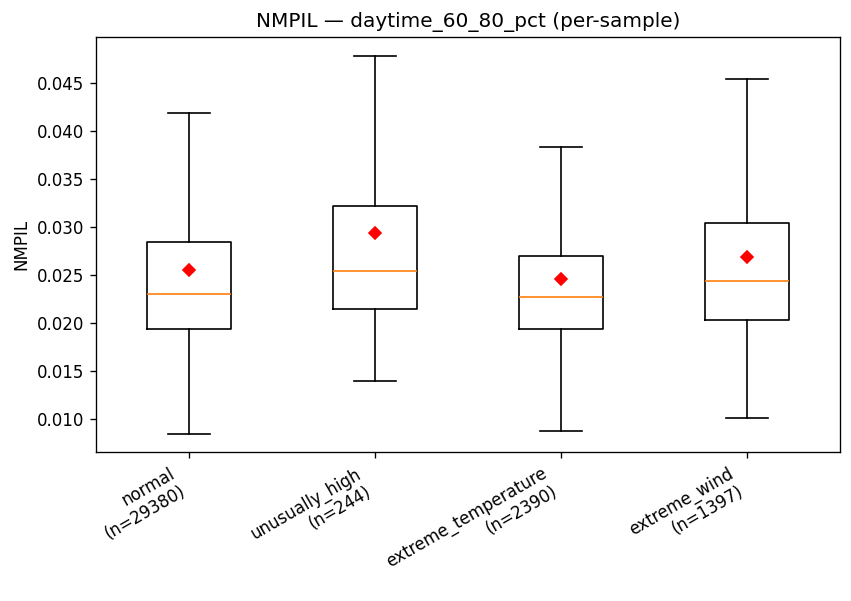

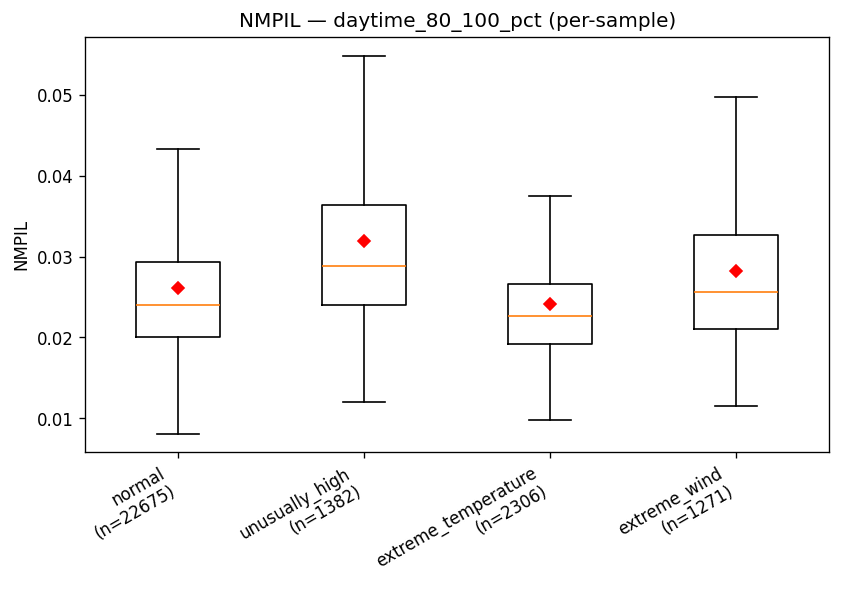

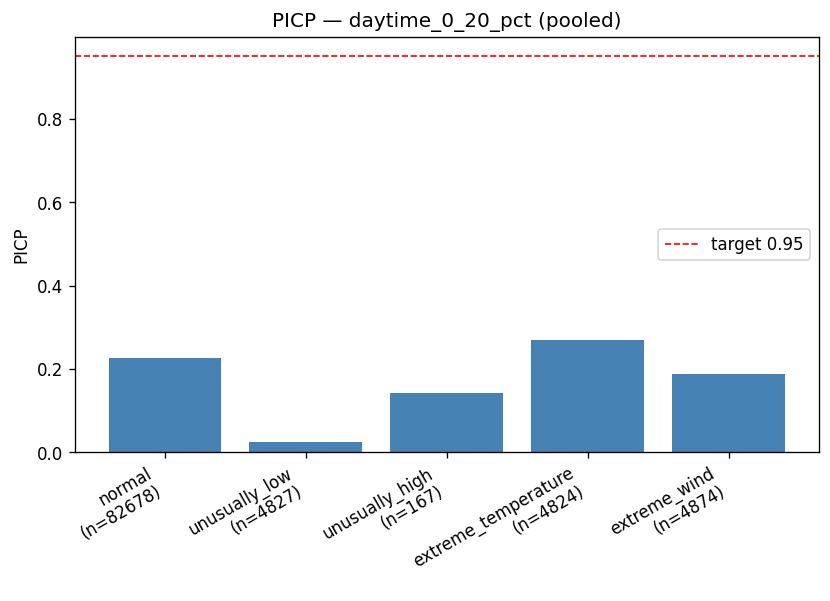

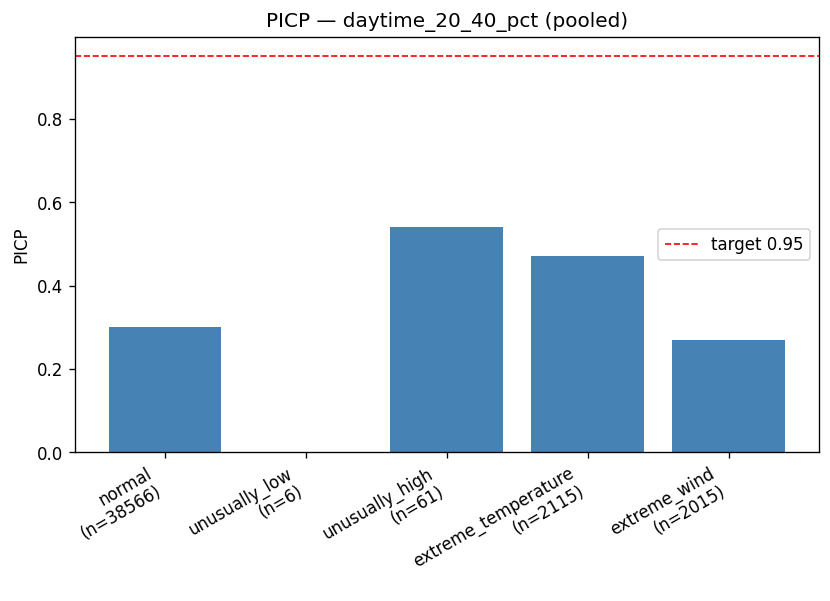

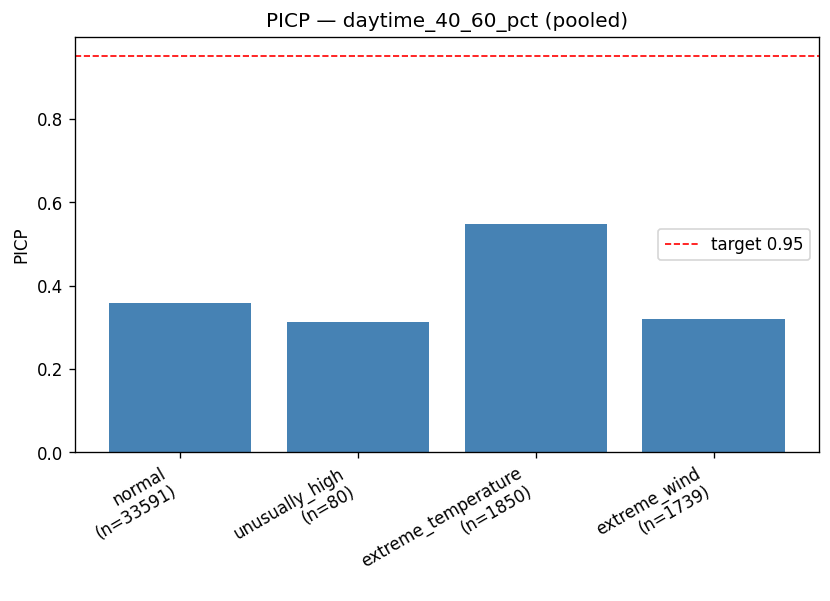

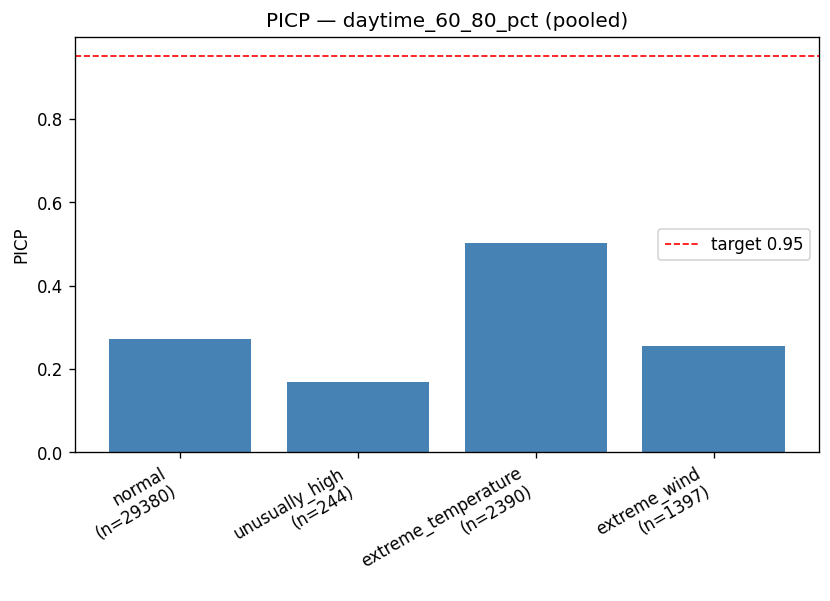

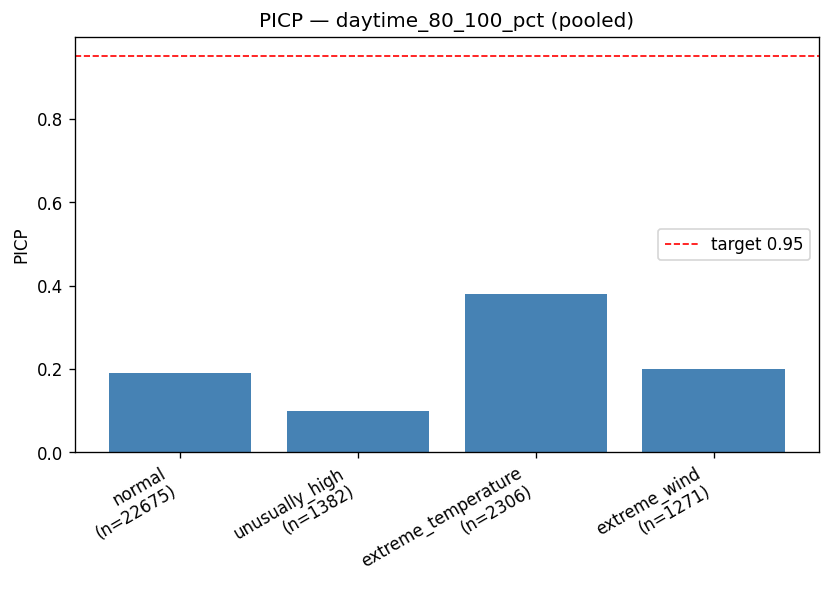

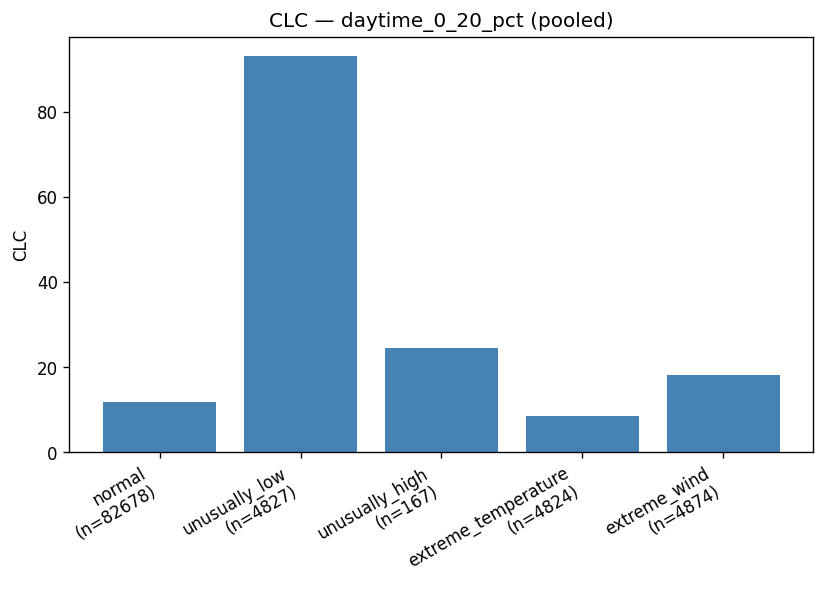

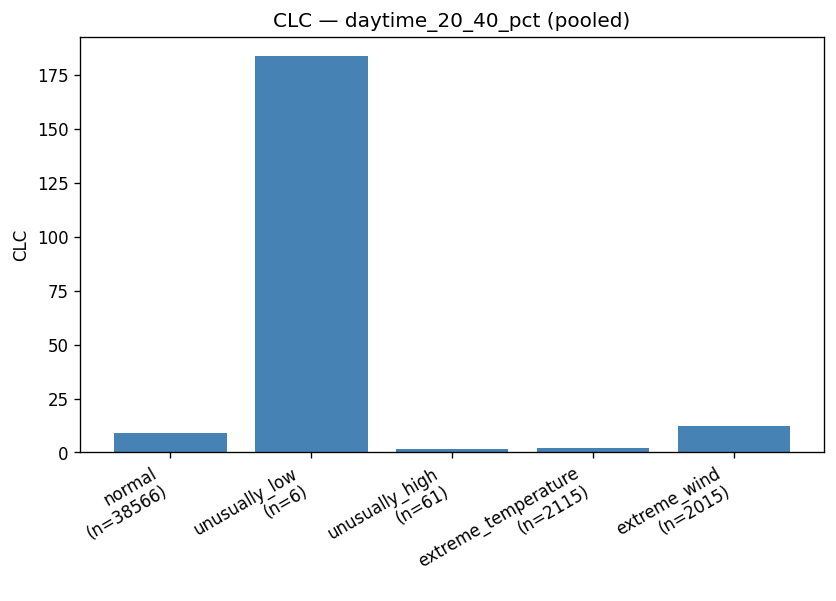

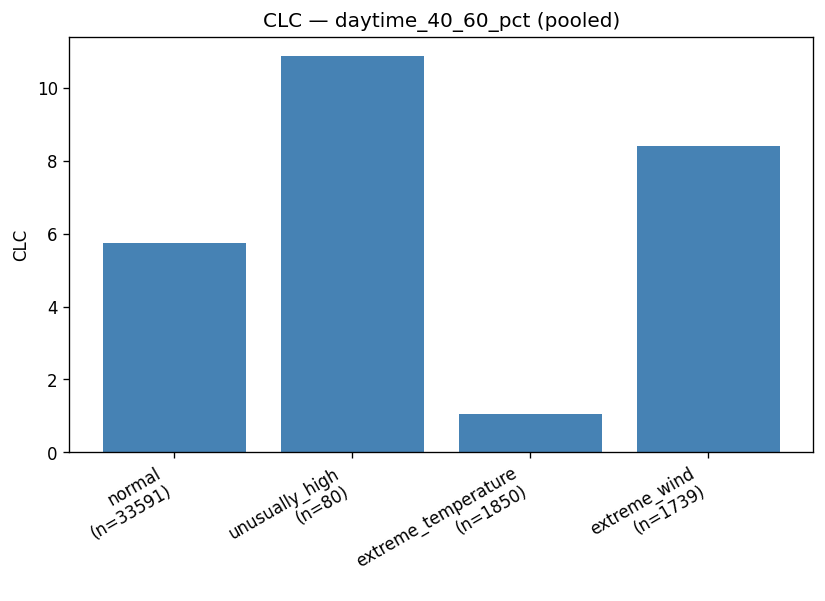

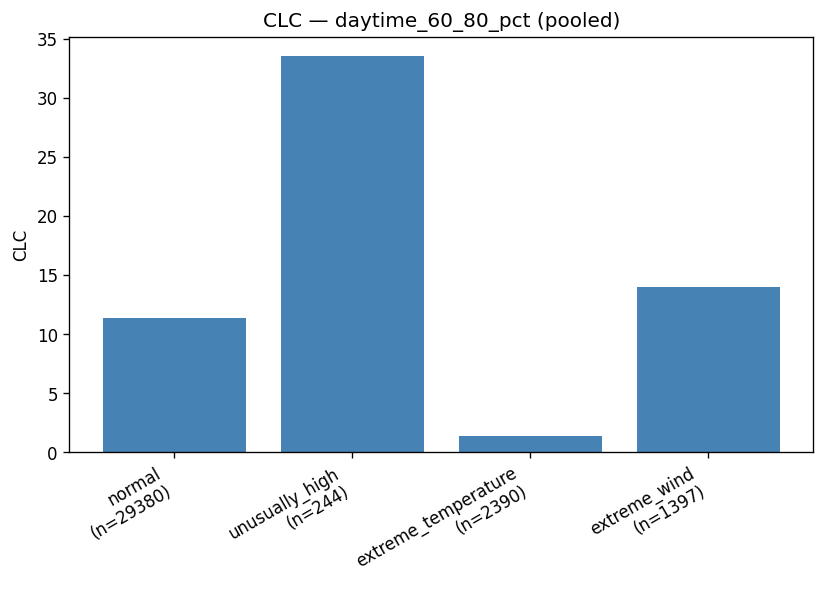

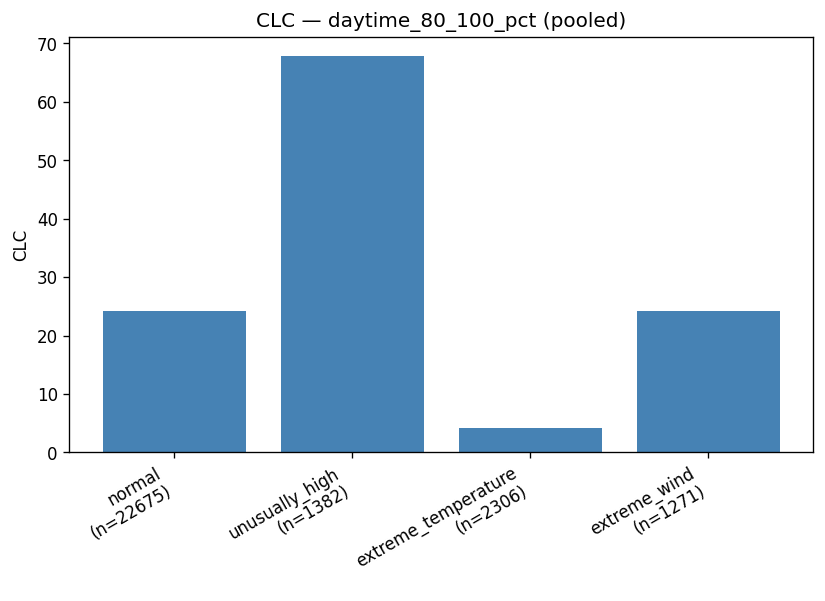

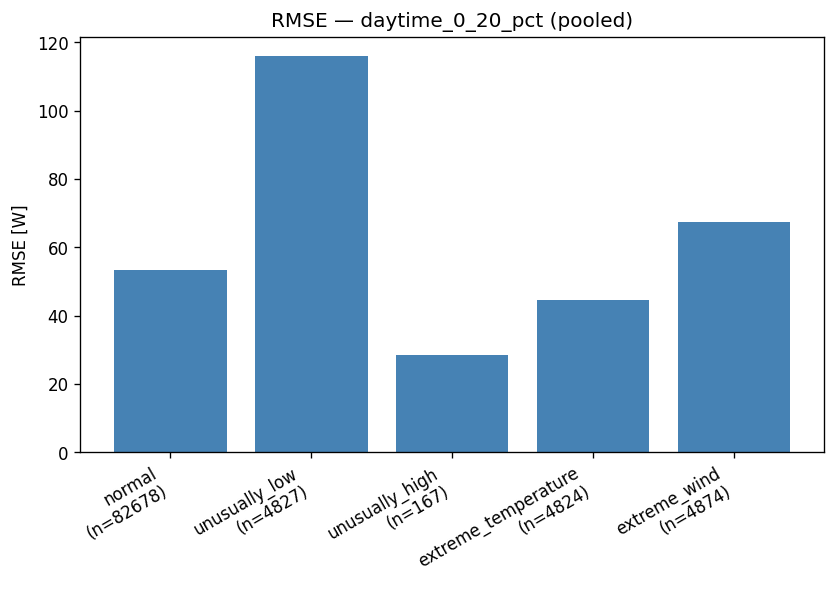

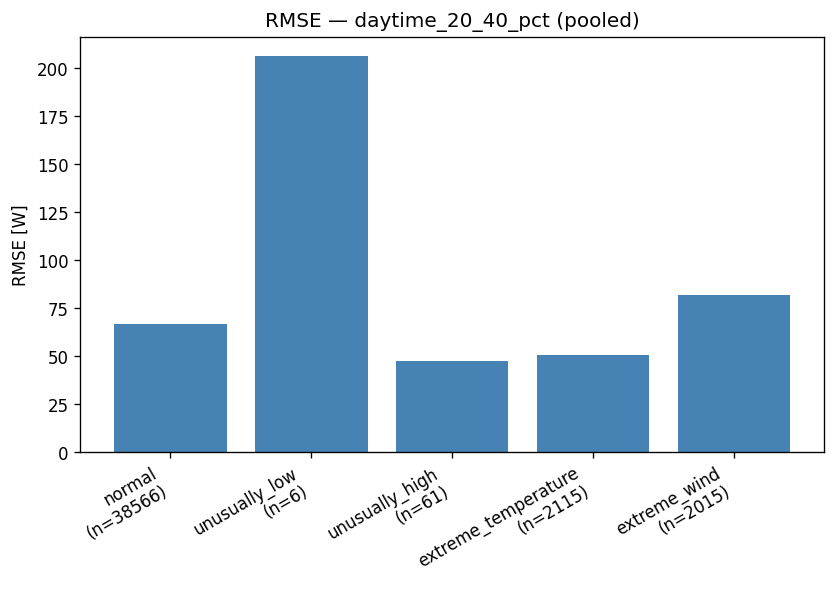

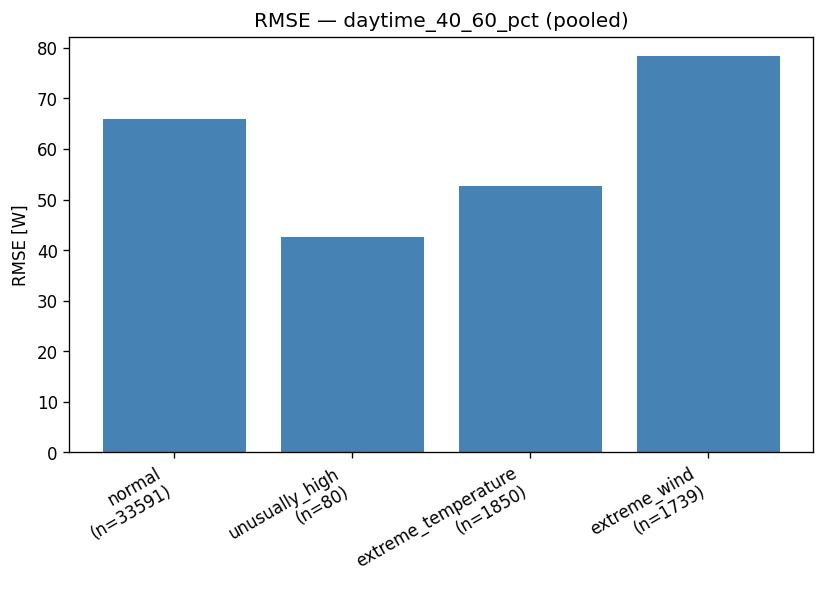

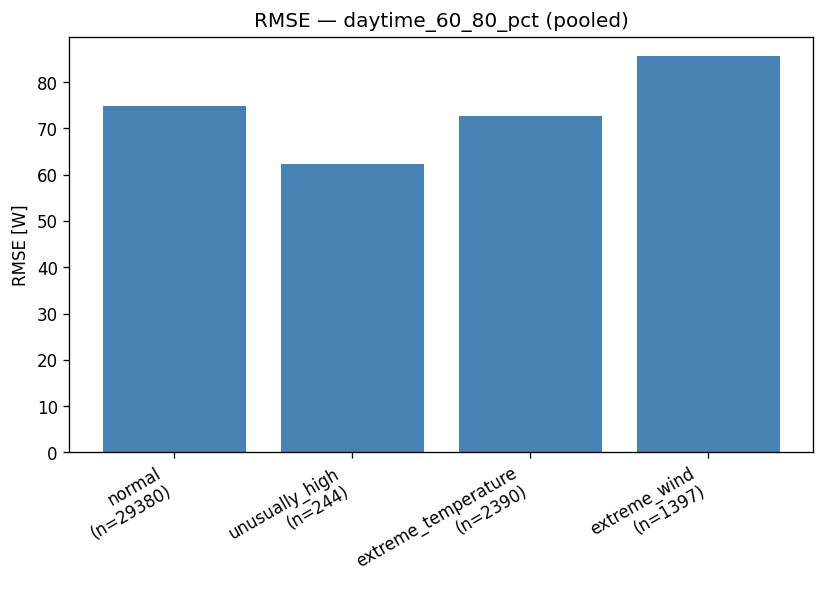

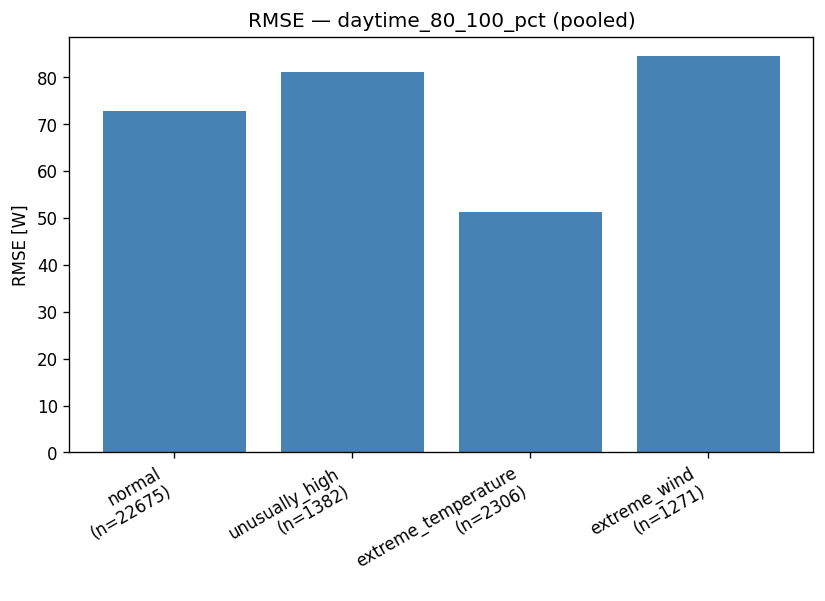

In [12]:
if figure_paths:
    from IPython.display import Image, display
    for path in figure_paths.values():
        display(Image(filename=str(path)))

## 7. W&B sweep (optional)

In [13]:
sweep_parameters = {
    'n_sde_steps': {'values': [2]},  # fixed: temporal stage + original single GAT stage
    'sigma_max': {'values': [0.3, 0.5]},
    'ood_noise_std': {'values': [1.0]},  # Monaco OOD train step: randn_like(x)+x (std 1.0)
}
sweep_config = pipe.make_sweep_config(sweep_parameters)
sweep_config

{'program': 'scripts/run_pvgis_sde_sweep_member.py',
 'method': 'grid',
 'metric': {'name': 'posthoc/daytime_picp', 'goal': 'maximize'},
 'parameters': {'n_sde_steps': {'values': [2]},
  'sigma_max': {'values': [0.3, 0.5]},
  'ood_noise_std': {'values': [1.0]}}}

In [14]:
CREATE_SWEEP = False  # set True to register the sweep on W&B
if CREATE_SWEEP:
    import wandb
    sweep_id = wandb.sweep(sweep_config, project=pipe.WANDB_PROJECT, entity=pipe.WANDB_ENTITY)
    print('sweep_id:', sweep_id)
    print('wandb agent ' + pipe.WANDB_ENTITY + '/' + pipe.WANDB_PROJECT + '/' + str(sweep_id))
else:
    print('Set CREATE_SWEEP=True to register. The agent runs the program in sweep_config:')
    print('  ' + pipe.SWEEP_MEMBER_SCRIPT)
    print('  wandb agent ' + pipe.WANDB_ENTITY + '/' + pipe.WANDB_PROJECT + '/<sweep_id>')

Set CREATE_SWEEP=True to register. The agent runs the program in sweep_config:
  scripts/run_pvgis_sde_sweep_member.py
  wandb agent albertopedalino-politecnico-di-torino/physiq_pv/<sweep_id>


## 8. Log post-hoc results to W&B (optional)

Adds post-hoc scalars and figures to the matching W&B run without uploading artifacts.
The sweep wrapper does this automatically per run.

In [15]:
LOG_TO_WANDB = True
if LOG_TO_WANDB:
    import wandb
    run = pipe.init_wandb_run_for_out_dir(wandb, out_dir, run_name=run_name)
    try:
        posthoc = pipe.log_posthoc_to_wandb(
            wandb, run, out_dir,
            figure_paths=figure_paths if 'figure_paths' in dir() else None,
            upload_artifact=False,
        )
        print(posthoc['summary'])
        print('posthoc artifact upload disabled; uploaded:', posthoc['artifact_uploaded'])
    finally:
        run.finish()
else:
    print('LOG_TO_WANDB is False. posthoc summary preview:')
    if Path(out_dir, 'sharpness_overview.csv').exists():
        print(pipe.read_posthoc_summary(out_dir))

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/apedalino/.netrc.
wandb: Currently logged in as: albertopedalino (albertopedalino-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


{'posthoc/daytime_picp': 0.2643366202953316, 'posthoc/daytime_mpiw': 20.21853415047527, 'posthoc/daytime_nmpil': 0.02267007569231, 'posthoc/normal_picp': 0.2638127428220888, 'posthoc/rare_extreme_picp': 0.2680232607352356, 'posthoc/unusually_low_picp': 0.0219579423333023, 'posthoc/high_production_picp': 0.2008856668133082, 'posthoc/gt100_picp': 0.2008856668133082}
posthoc artifact upload disabled; uploaded: False


posthoc/daytime_mpiw,▁
posthoc/daytime_nmpil,▁
posthoc/daytime_picp,▁
posthoc/gt100_picp,▁
posthoc/high_production_picp,▁
posthoc/normal_picp,▁
posthoc/rare_extreme_picp,▁
posthoc/unusually_low_picp,▁
best_epoch,60
best_validation_metric,rmse_daytime
best_validation_score,59.56518
